### Load and Modify Configuration File

In [1]:
from configs.config_loader import load_config
config = load_config('configs/default.yaml')

version : default
seed : 1
y0 : 0.25
T : 20
N_col : 1024
N_hidden : 4
N_neurons : 50
activation : swish
N_epochs : 20000
learning_rate : 0.001
decay_rate : 1.0
freq_log : 100
freq_print : 1000
keys_print : ['loss']
freq_save : 100
regularization : no_reg
reg_coeff : 1.0
reg_decay : linear
reg_epochs : 0.5
eps : 0.01


### Initialize Physics-Informed Neural Network

In [2]:
from model.neural_net import PhysicsInformedNN
PINN = PhysicsInformedNN(config, verbose=True)

2026-02-04 21:48:40.530281: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-04 21:48:40.542705: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770238120.555468   10905 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770238120.559123   10905 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-04 21:48:40.573762: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Model: "nested_PINN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,801 (30.47 KB)

 Trainable params: 7,801 (30.47 KB)

 Non-trainable params: 0 (0.00 B)

*** PINN build & initialized ***


### Train Physics-Informed Neural Network

In [3]:
training_log = PINN.train()

Training started...
    0/20000 | loss: 5.22e-02
 1000/20000 | loss: 5.04e-03
 2000/20000 | loss: 6.87e-03
 3000/20000 | loss: 5.94e-03
 4000/20000 | loss: 6.11e-03
 5000/20000 | loss: 5.90e-03
 6000/20000 | loss: 6.73e-03
 7000/20000 | loss: 5.85e-03
 8000/20000 | loss: 6.92e-03
 9000/20000 | loss: 6.20e-03
10000/20000 | loss: 4.21e-03
11000/20000 | loss: 6.31e-03
12000/20000 | loss: 6.80e-03
13000/20000 | loss: 6.18e-03
14000/20000 | loss: 6.25e-03
15000/20000 | loss: 5.55e-03
16000/20000 | loss: 6.39e-03
17000/20000 | loss: 5.62e-03
18000/20000 | loss: 6.50e-03
19000/20000 | loss: 8.52e-03
------------
logs/default
*** logs saved ***
### Training finished ###


# Plot Section

In [ ]:
from model.plots import learning_curves, toy_example_dynamics, loss_over_tcoll, plot_regularization, regularization_over_domain, plot_EL_loss

### Learning Curves

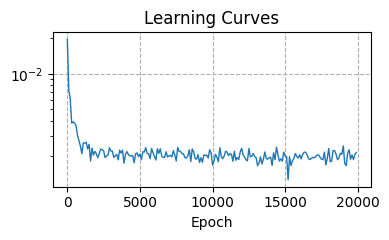

In [ ]:
learning_curves(training_log)

### Toy Example Dynamics

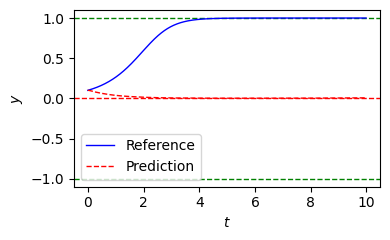

In [ ]:
toy_example_dynamics(PINN)

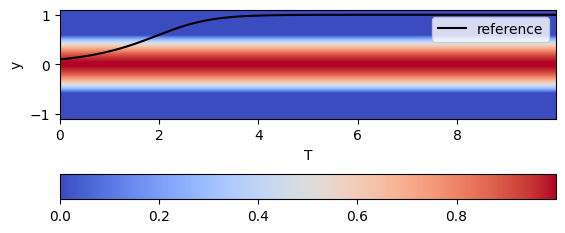

In [ ]:
regularization_over_domain(PINN)

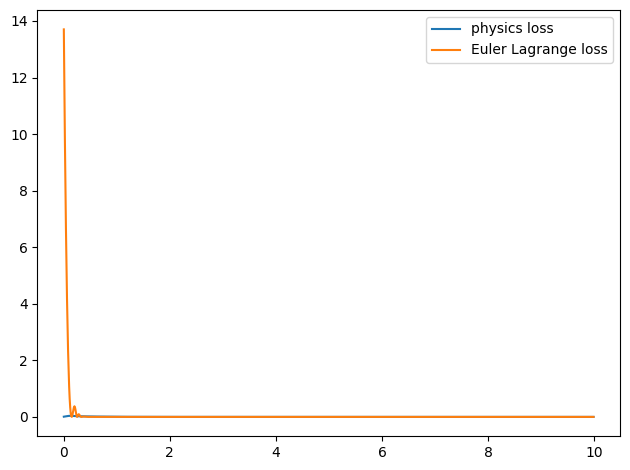

In [ ]:
plot_EL_loss(PINN)

(1000, 1)
(1000, 1)


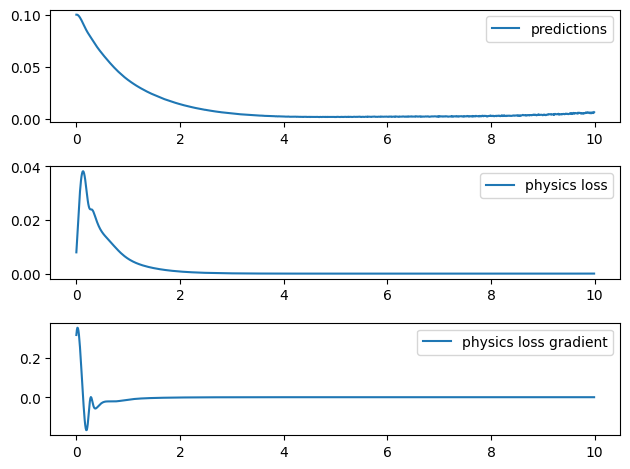

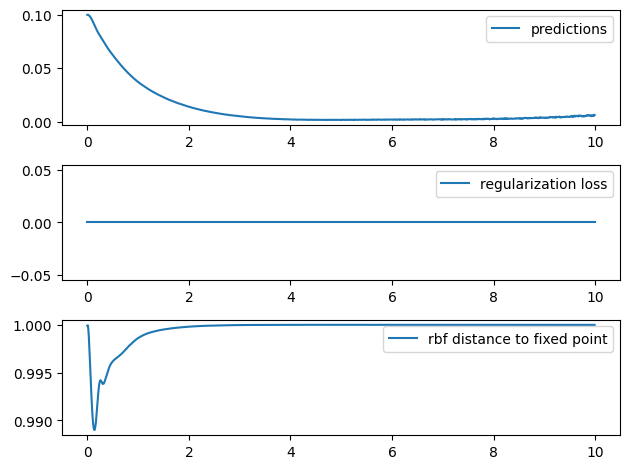

In [ ]:
import tensorflow as tf

t_col = PINN.data.t_line()
pred = PINN(t_col)

print(t_col.shape)
print(pred.shape)

loss_over_tcoll(PINN)

plot_regularization(PINN)


### Training animation

In [ ]:
import matplotlib.pyplot as plt
import os
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML



def init_fig():

    fig, ax = plt.subplots()

    #############################
    ### Initial plot comes here
    #############################

    plt.tight_layout()
    plt.close(fig)
    return fig, ax


def animate(i, *fargs):
    # get passed arguments
    ax = fargs[0]
    N_times = fargs[1]

    # print status of animation
    print(f'Processed: {i/N_times*100:.0f}%', end='\r')

    # clear axis
    ax.clear()

    #############################
    ### load model weights & make predictions
    #############################
    flag = i * config['freq_save']
    PINN.load_weights(PINN.log_path.joinpath(f'model_weights/weights_{flag}.pkl'))
    # get (equally-spaced) data points
    t_line = PINN.data.t_line()
    # get reference solution (analytical)
    y_true = PINN.data.reference(t_line)
    # get PINN prediction
    y_pred = PINN(t_line)

    #############################
    ### Updated plot comes here
    #############################

    # include fixed point lines
    for y_fix in [-1, 1]:
        ax.axhline(y_fix, lw=1, ls='--', c='green')
    ax.axhline(0, lw=1, ls='--', c='red')

    # make plots
    ax.plot(t_line, y_true, c='blue', lw=1, label='Reference')
    ax.plot(t_line, y_pred, c='red', lw=1, ls='--', label='Prediction')

    # Axis appearance
    ax.legend()
    ax.set_ylabel(r'$y$')
    ax.set_xlabel(r'$t$')


    plt.tight_layout()


# should equal the number of saved weights files
N_frames = int(config["N_epochs"] / config["freq_save"])

(fig, ax) = init_fig()
ani = FuncAnimation(fig, animate, frames=N_frames, fargs=(ax, N_frames))
HTML(ani.to_jshtml())

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import numpy as np
from model.plots import results_heatmap

results = pd.read_csv("results.csv")

results_heatmap(results)

FileNotFoundError: [Errno 2] No such file or directory: 'results.csv'

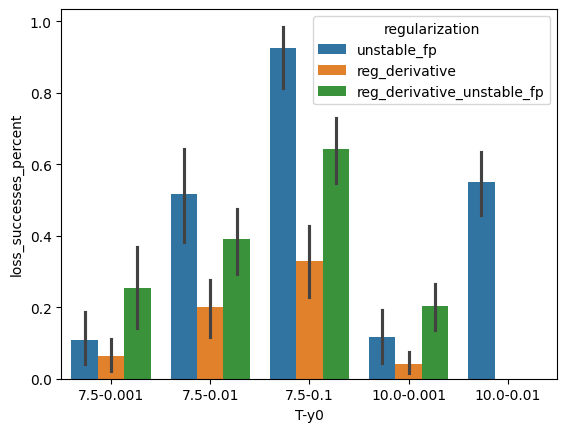

In [ ]:
from model.plots import plot_comparissons
import pandas as pd

results = pd.read_csv("results_linear_decay.csv")

plot_comparissons(results=results)

